## 1. Importing the libraries

In [1]:
!pip install plotly

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "svg"

## 2. Importing the dataset

In [3]:
raw_df = pd.read_csv('Zomato_Chennai_Dataset.csv')

In [4]:
raw_df.head()

,Zomato URL,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,https://www.zomato.com/chennai/yaa-mohaideen-b...,Yaa Mohaideen Briyani,"336 & 338, Main Road, Pallavaram, Chennai",Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,https://www.zomato.com/chennai/sukkubhai-biriy...,Sukkubhai Biriyani,"New 14, Old 11/3Q, Railway Station Road, MKN ...",Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,https://www.zomato.com/chennai/ss-hyderabad-bi...,SS Hyderabad Biryani,"98/339, Arcot Road, Opposite Gokulam Chit Fun...",Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,https://www.zomato.com/chennai/kfc-perambur,KFC,"10, Periyar Nagar, 70 Feet Road, Near Sheeba ...",Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,https://www.zomato.com/chennai/tasty-kitchen-p...,Tasty Kitchen,"135B, SRP Colony, Peravallur, Near Perambur, ...",Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"


## 3. Getting Basic Information about the Dataset

In [5]:
raw_df.shape

(12032, 12)

In [6]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12032 entries, 0 to 12031
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Zomato URL             12032 non-null  object 
 1   Name of Restaurant     12032 non-null  object 
 2   Address                12032 non-null  object 
 3   Location               12032 non-null  object 
 4   Cuisine                12032 non-null  object 
 5   Top Dishes             12032 non-null  object 
 6   Price for 2            12032 non-null  float64
 7   Dining Rating          6681 non-null   float64
 8   Dining Rating Count    11812 non-null  object 
 9   Delivery Rating        6181 non-null   float64
 10  Delivery Rating Count  11812 non-null  object 
 11  Features               12032 non-null  object 
dtypes: float64(3), object(9)
memory usage: 1.1+ MB


In [7]:


# 1. Identify rows where the value cannot be converted to a number
# errors='coerce' turns non-numeric strings into NaN
is_not_numeric = pd.to_numeric(raw_df['Delivery Rating Count'], errors='coerce').isna()

# 2. Filter the original dataframe to see these categorical values
# We use .unique() to get a clean list of the unique labels
categorical_labels = raw_df.loc[is_not_numeric, 'Delivery Rating Count'].unique()

print("Categorical values in 'Delivery Rating Count':")
print(categorical_labels)


Categorical values in 'Delivery Rating Count':
['Does not offer Delivery' 'Not enough Delivery Reviews' nan]


In [8]:
raw_df.describe()

,Price for 2,Dining Rating,Delivery Rating
count,12032.000000,6681.000000,6181.000000
mean,397.611370,3.387756,3.805290
std,332.045938,0.558181,0.374213
min,40.000000,0.300000,0.300000
25%,200.000000,3.100000,3.600000
50%,300.000000,3.500000,3.900000
75%,450.000000,3.800000,4.000000
max,5000.000000,4.900000,4.700000


In [9]:
raw_df.describe(include=['O'])

,Zomato URL,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Dining Rating Count,Delivery Rating Count,Features
count,12032,12032,12032,12032,12032,12032,11812,11812,12032
unique,12032,8369,10828,268,2423,2190,793,2281,1554
top,https://www.zomato.com/chennai/yaa-mohaideen-b...,Amma Unavagam,Delivery Only,Porur,['South Indian'],Invalid,Does not offer Dining,Not enough Delivery Reviews,"['Home Delivery', 'Indoor Seating']"
freq,1,78,443,418,883,9641,2603,3379,2447


## 4. Cleaning the Dataset

In [10]:
# Dropping columns which are not required for further analysis
raw_df.drop(['Zomato URL', 'Address'], axis=1, inplace=True)

### b. Removing the Null Records

In [11]:
# Checking for Null records
raw_df.isnull().sum()

Name of Restaurant          0
Location                    0
Cuisine                     0
Top Dishes                  0
Price for 2                 0
Dining Rating            5351
Dining Rating Count       220
Delivery Rating          5851
Delivery Rating Count     220
Features                    0
dtype: int64

In [12]:
raw_df["Dining Rating"].value_counts()

Dining Rating
3.6    584
3.5    553
3.7    525
3.4    500
3.3    463
3.8    460
3.2    433
3.9    379
3.1    363
2.0    354
3.0    302
4.0    288
2.9    257
4.1    221
2.8    192
4.2    142
2.7    138
4.3    105
2.6     99
2.5     71
4.4     61
2.4     46
4.5     36
2.3     32
2.2     20
4.6     17
4.7     12
2.1     10
4.9      7
4.8      4
1.9      3
1.7      2
0.3      1
1.0      1
Name: count, dtype: int64

In [13]:
# 1. Fill ALL nulls with 0 first
raw_df[['Dining Rating', 'Delivery Rating']] = raw_df[['Dining Rating', 'Delivery Rating']].fillna(0)

# 2. Define rows where BOTH are 0
new_restaurants = (raw_df['Dining Rating'] == 0) | (raw_df['Delivery Rating'] == 0)

# 3. Create the cleaned dataframe by EXCLUDING those rows
cleaned_df = raw_df[~new_restaurants].copy()


print(cleaned_df.isnull().sum())


Name of Restaurant       0
Location                 0
Cuisine                  0
Top Dishes               0
Price for 2              0
Dining Rating            0
Dining Rating Count      0
Delivery Rating          0
Delivery Rating Count    0
Features                 0
dtype: int64


In [14]:
# Create a separate dataset for the "useless" data
new_restaurants_df = raw_df[new_restaurants].copy()

# Display the results
print(f"Total 'new_restaurants' rows: {len(new_restaurants_df)}")
new_restaurants_df


Total 'new_restaurants' rows: 7651


,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
6,Bai Veetu Kalyanam,Navallur,['Biryani'],"['Bread Halwa', ' Mutton Biryani', ' Brinjal G...",350.0,0.0,Does not offer Dining,4.3,1061,['Home Delivery']
15,Welcome Hotel,Purasavakkam,"['South Indian', ' Desserts', ' Beverages']","['Pongal', ' Podi Dosa', ' Idli Sambar', ' Vad...",300.0,4.5,1094,0.0,Does not offer Delivery,"['Breakfast', 'Vegetarian Only', 'Indoor Seati..."
18,Wire Room Bar & Kitchen,"Phoenix Market City, Velachery","['Continental', ' Asian']","['Cocktails', ' Salad', ' Beer', ' Tikka', ' P...",2000.0,4.1,354,0.0,Does not offer Delivery,"['Full Bar Available', 'Mall Parking', 'Dance ..."
23,BFF 2.0,RA Puram,"['North Indian', ' Continental', ' Italian']","['Crispy Chicken', ' Cocktails', ' Pizza', ' N...",1500.0,4.2,464,0.0,Does not offer Delivery,"['Full Bar Available', 'Indoor Seating', 'Nigh..."
77,Al Dhareeq Beef Biriyani,Kodambakkam,['Biryani'],['Beef Biryani'],300.0,0.0,Does not offer Dining,3.9,19600,['Home Delivery']
...,...,...,...,...,...,...,...,...,...,...
12027,CK's Sandwiches,Porur,['Sandwich'],Invalid,350.0,0.0,NaN,0.0,NaN,"['Breakfast', 'Delivery Only']"
12028,CK's Sandwiches,Kolathur,['Sandwich'],Invalid,350.0,0.0,NaN,0.0,NaN,"['Breakfast', 'Delivery Only']"
12029,CK's Sandwiches,Anna Nagar East,['Sandwich'],Invalid,350.0,0.0,NaN,0.0,NaN,"['Breakfast', 'Delivery Only']"
12030,CK's Sandwiches,Ramapuram,['Sandwich'],Invalid,350.0,0.0,NaN,0.0,NaN,"['Breakfast', 'Delivery Only']"


In [15]:
cleaned_df

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,Sukkubhai Biriyani,Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,SS Hyderabad Biryani,Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,KFC,Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,Tasty Kitchen,Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"
...,...,...,...,...,...,...,...,...,...,...
11666,Juice World,Alandur,"['Beverages', ' Fast Food']",Invalid,300.0,2.0,4,3.9,42,"['Home Delivery', 'Vegetarian Only', 'Indoor S..."
11667,Juice World,Palavakkam,"['Beverages', ' Fast Food']",Invalid,300.0,2.0,4,3.9,48,"['Home Delivery', 'Vegetarian Only', 'Indoor S..."
11736,Adyar Vaishnavas Thattu Idly Kadai,Porur,"['South Indian', ' Sandwich', ' Chinese', ' St...",Invalid,200.0,3.2,6,3.9,48,"['Home Delivery', 'Indoor Seating']"
11785,Engineers Kitchen,Ambattur,"['North Indian', ' Chinese', ' Andhra']",Invalid,400.0,2.5,6,3.5,214,"['Home Delivery', 'Indoor Seating']"


In [16]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4381 entries, 0 to 11794
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Name of Restaurant     4381 non-null   object 
 1   Location               4381 non-null   object 
 2   Cuisine                4381 non-null   object 
 3   Top Dishes             4381 non-null   object 
 4   Price for 2            4381 non-null   float64
 5   Dining Rating          4381 non-null   float64
 6   Dining Rating Count    4381 non-null   object 
 7   Delivery Rating        4381 non-null   float64
 8   Delivery Rating Count  4381 non-null   object 
 9   Features               4381 non-null   object 
dtypes: float64(3), object(7)
memory usage: 376.5+ KB


In [17]:
zomato_chennai_df =cleaned_df.copy()

In [18]:
zomato_chennai_df.head()

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,Sukkubhai Biriyani,Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,SS Hyderabad Biryani,Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,KFC,Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,Tasty Kitchen,Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"


In [19]:
raw_df["Location"].value_counts()

Location
Porur                                                       418
Velachery                                                   372
Ambattur                                                    334
T. Nagar                                                    315
Perungudi                                                   288
                                                           ... 
Hotel Peninsula, T. Nagar                                     1
Vivira Mall, Navallur                                         1
Hotel NRS Sakithyan, T. Nagar                                 1
RMZ Millenia Business Park, Old Mahabalipuram Road (OMR)      1
Chandra Metro Mall, Virugambakkam                             1
Name: count, Length: 268, dtype: int64

## 5. Performing Exploratory Data Analysis

### Q1) How many restaurants are in chennai for each location?

In [20]:
!pip install -U kaleido

In [21]:
import pandas as pd

# 1. Ensure all 205 rows are displayed
pd.set_option('display.max_rows', 300)

# 2. Create the pivot table for counts
pivot_counts = raw_df.pivot_table(
    index='Location', 
    values='Name of Restaurant', 
    aggfunc='count'
)

# 3. Rename the column
pivot_counts.columns = ['Restaurant Count']

# 4. SORT from MAX to MIN (Descending order)
pivot_counts = pivot_counts.sort_values(by='Restaurant Count', ascending=False)

# 5. Display the full table
pivot_counts


,Restaurant Count
Location,
Porur,418
Velachery,372
Ambattur,334
T. Nagar,315
Perungudi,288
Anna Nagar East,285
Perambur,275
Medavakkam,271
Tambaram,258


### Q2) What are the percentage of restaurants by Dining Rating Type in Chennai?

In [22]:
rating_type_df = zomato_chennai_df['Dining Rating'].value_counts().reset_index(name='COUNT OF RESTAURANTS')
# This usually results in ['RATING_TYPE', 'COUNT OF RESTAURANTS']


In [23]:
rating_type_df

,Dining Rating,COUNT OF RESTAURANTS
0,3.7,387
1,3.6,377
2,3.5,359
3,3.8,334
4,3.4,324
5,3.9,301
6,3.3,294
7,3.2,262
8,3.1,236
9,4.0,222


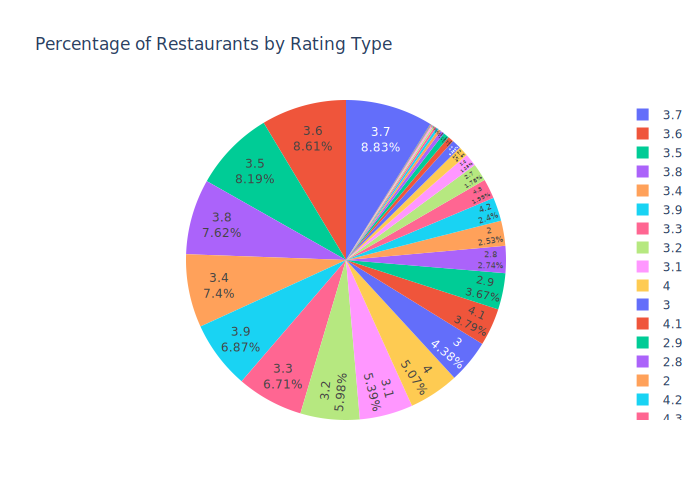

In [24]:
fig = px.pie(rating_type_df, names='Dining Rating', values='COUNT OF RESTAURANTS', color='Dining Rating',
             title='Percentage of Restaurants by Rating Type').update_traces(textposition='inside', textinfo='percent+label')
fig.show()

### Q3) Which are the Top 10 highest rated Restaurant in Chennai?

In [25]:
zomato_chennai_df.sort_values(by='Dining Rating', ascending=False).head(10)

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
57,Brownie Heaven,Royapettah,"['Bakery', ' Desserts', ' Beverages']","['Vanilla Ice Cream', ' Brownie Shake', ' Filt...",350.0,4.9,842,4.3,2270,"['Home Delivery', 'Indoor Seating', 'Desserts ..."
184,Gossip Fusion Bistro,Kanathur,"['Italian', ' Continental', ' Burger', ' Sandw...","['Tender Coconut Mousse', ' Iced Tea', ' Pasta...",1500.0,4.9,996,4.3,500,"['Breakfast', 'Home Delivery', 'Free Parking',..."
219,Prems Graama Bhojanam,Adyar,['South Indian'],"['Benne Dosa', ' Buttermilk', ' Thatte Idli', ...",500.0,4.9,1511,4.1,4621,"['Home Delivery', 'Vegetarian Only', 'Indoor S..."
320,Bombay Kulfi,Adyar,['Ice Cream'],"['Kesar Pista Kulfi', ' Malai Kulfi', ' Chocol...",200.0,4.9,534,4.3,1476,"['Home Delivery', 'Free Parking', 'Outdoor Sea..."
192,Kabab Corner,Egmore,"['Kebab', ' Rolls', ' Mughlai']","['Rolls', ' Beef Fry', ' Beef Steak', ' Chicke...",450.0,4.9,1053,4.3,2080,"['Home Delivery', 'Indoor Seating', 'Catering ..."
105,Bhangra,"Mayajaal Multiplex, Kanathur",['North Indian'],"['Butter Chicken', ' Dal Makhani', ' Sweet Las...",800.0,4.9,2109,4.0,2226,"['Breakfast', 'Home Delivery', 'Mall Parking',..."
155,The Sandwich Shop,West Mambalam,"['Sandwich', ' Fast Food', ' Beverages']","['Mocktails', ' Fries', ' Pizza Sandwich', ' T...",300.0,4.9,584,4.4,895,"['Home Delivery', 'Vegetarian Only', 'Bulk Ord..."
62,Amadora Gourmet Ice Cream & Sorbet,Nungambakkam,"['Desserts', ' Ice Cream']","['Sandwich', ' Gelato', ' Chocolate Icecreams'...",500.0,4.8,1516,4.5,361,"['Home Delivery', 'Outdoor Seating', 'Desserts..."
195,The Marina,Nungambakkam,"['Seafood', ' North Indian', ' Chinese']","['Sea Food', ' Jumbo Prawns', ' Biryani', ' Fi...",1600.0,4.8,1082,4.3,373,"['Home Delivery', 'Indoor Seating', 'Table res..."
163,Momo Sa-Khang by Kailash Kitchen,Choolaimedu,"['Momos', ' Chinese']","['Momos', ' Noodle', ' Chowmein', ' Fried Momo...",350.0,4.8,1658,4.5,2825,"['Home Delivery', 'Free Parking', 'Indoor Seat..."


### Q4) Top 5 bast delivery reating restaurant in chennai

In [26]:
zomato_chennai_df.sort_values(by='Delivery Rating', ascending=False).head(5)

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
1985,Arabian Plate,Adambakkam,"['Arabian', ' Biryani']",Invalid,300.0,3.7,58,4.7,491,"['Home Delivery', 'Indoor Seating']"
4371,Mumbai Kulfi,Pallavaram,['Desserts'],Invalid,150.0,3.7,11,4.7,141,"['Home Delivery', 'Free Parking', 'Outdoor Sea..."
9977,ibaco,Mylapore,['Ice Cream'],['Brownie'],200.0,3.6,55,4.7,230,"['Home Delivery', 'Vegetarian Only', 'Desserts..."
2151,Cane 4 U,Besant Nagar,['Beverages'],"['Sugarcane Juice', ' Fruit Juices']",100.0,3.8,52,4.6,160,"['Home Delivery', 'Indoor Seating']"
9954,ibaco,T. Nagar,['Ice Cream'],"['Icecream Cake', ' Raj Bhog']",200.0,4.0,172,4.6,519,"['Home Delivery', 'Vegetarian Only', 'Valet Pa..."


### Q5) Which places have the highest rated restaurant in Chennai?

In [27]:
# Assuming restaurants having rating above 4.
highest_rated_df = zomato_chennai_df[zomato_chennai_df['Dining Rating'] >= 4.8]
highest_rated_df

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
57,Brownie Heaven,Royapettah,"['Bakery', ' Desserts', ' Beverages']","['Vanilla Ice Cream', ' Brownie Shake', ' Filt...",350.0,4.9,842,4.3,2270,"['Home Delivery', 'Indoor Seating', 'Desserts ..."
62,Amadora Gourmet Ice Cream & Sorbet,Nungambakkam,"['Desserts', ' Ice Cream']","['Sandwich', ' Gelato', ' Chocolate Icecreams'...",500.0,4.8,1516,4.5,361,"['Home Delivery', 'Outdoor Seating', 'Desserts..."
105,Bhangra,"Mayajaal Multiplex, Kanathur",['North Indian'],"['Butter Chicken', ' Dal Makhani', ' Sweet Las...",800.0,4.9,2109,4.0,2226,"['Breakfast', 'Home Delivery', 'Mall Parking',..."
155,The Sandwich Shop,West Mambalam,"['Sandwich', ' Fast Food', ' Beverages']","['Mocktails', ' Fries', ' Pizza Sandwich', ' T...",300.0,4.9,584,4.4,895,"['Home Delivery', 'Vegetarian Only', 'Bulk Ord..."
163,Momo Sa-Khang by Kailash Kitchen,Choolaimedu,"['Momos', ' Chinese']","['Momos', ' Noodle', ' Chowmein', ' Fried Momo...",350.0,4.8,1658,4.5,2825,"['Home Delivery', 'Free Parking', 'Indoor Seat..."
184,Gossip Fusion Bistro,Kanathur,"['Italian', ' Continental', ' Burger', ' Sandw...","['Tender Coconut Mousse', ' Iced Tea', ' Pasta...",1500.0,4.9,996,4.3,500,"['Breakfast', 'Home Delivery', 'Free Parking',..."
192,Kabab Corner,Egmore,"['Kebab', ' Rolls', ' Mughlai']","['Rolls', ' Beef Fry', ' Beef Steak', ' Chicke...",450.0,4.9,1053,4.3,2080,"['Home Delivery', 'Indoor Seating', 'Catering ..."
195,The Marina,Nungambakkam,"['Seafood', ' North Indian', ' Chinese']","['Sea Food', ' Jumbo Prawns', ' Biryani', ' Fi...",1600.0,4.8,1082,4.3,373,"['Home Delivery', 'Indoor Seating', 'Table res..."
219,Prems Graama Bhojanam,Adyar,['South Indian'],"['Benne Dosa', ' Buttermilk', ' Thatte Idli', ...",500.0,4.9,1511,4.1,4621,"['Home Delivery', 'Vegetarian Only', 'Indoor S..."
320,Bombay Kulfi,Adyar,['Ice Cream'],"['Kesar Pista Kulfi', ' Malai Kulfi', ' Chocol...",200.0,4.9,534,4.3,1476,"['Home Delivery', 'Free Parking', 'Outdoor Sea..."


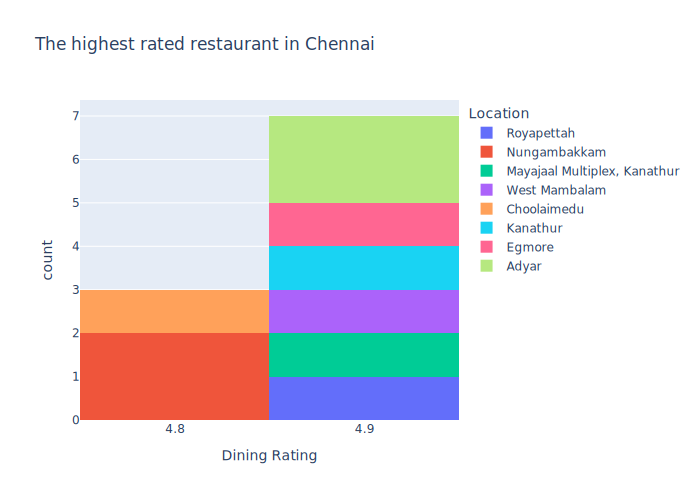

In [28]:
fig = px.histogram(highest_rated_df, x='Dining Rating', color='Location',
                   title='The highest rated restaurant in Chennai').update_xaxes(categoryorder="total descending")
fig.show()

### Q6) What is the Avg Price Distribution of highest rated restaurant in Chennai?

In [29]:
highest_rated_price_df = highest_rated_df.groupby(by=['Location'])['Price for 2'].mean().reset_index()
highest_rated_price_df.head()

,Location,Price for 2
0,Adyar,350.0
1,Choolaimedu,350.0
2,Egmore,450.0
3,Kanathur,1500.0
4,"Mayajaal Multiplex, Kanathur",800.0


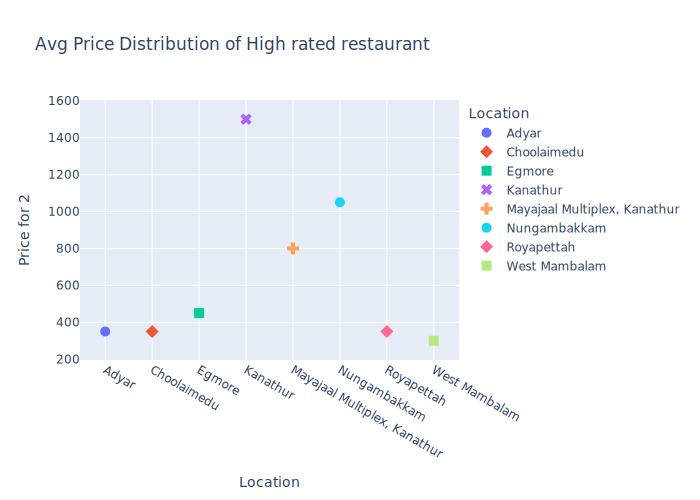

In [30]:
fig = px.scatter(highest_rated_price_df, x="Location", y="Price for 2", color="Location", symbol="Location",
                 title='Avg Price Distribution of High rated restaurant').update_traces(marker_size=10)
fig.show()

### Q7) Is there a relation between Location and Price?

In [31]:
region_price_df = zomato_chennai_df.groupby(['Location'])['Price for 2'].mean().reset_index()


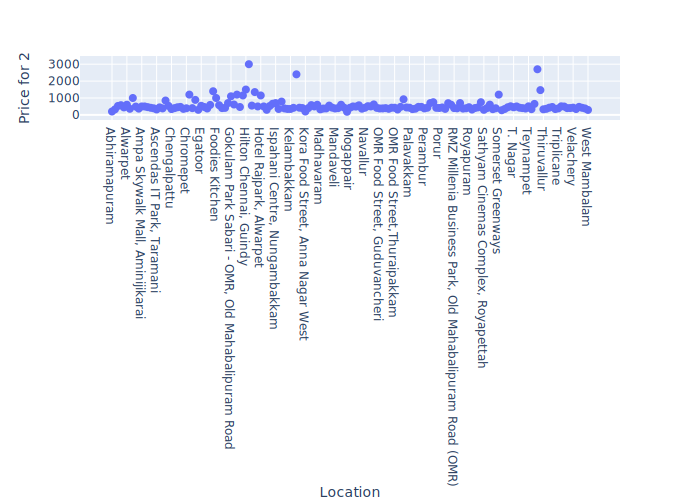

In [32]:
fig = px.scatter(region_price_df, x="Location", y="Price for 2").update_traces(marker_size=8)
fig.show()

### Q08) Find the list of Affordable Restaurants?

**The criteria for Affordable Restaurants would be:**
1. Low Price
2. High Rated

First step will be to find the restaurants with average cost 1/4th the average cost of most expensive restaurant in our dataframe.

The most expensive restaurant has an average meal cost = 6000. We'll try to stay economical and only pick the restaurants that are 1/4th of 6000.

In [33]:
max_price = zomato_chennai_df['Price for 2'].max()
one_fourth_price = max_price / 4
one_fourth_price

np.float64(750.0)

In [34]:
# Finding list of restaurants that have price less than and equal to 1/4th of the max price i.e Finding Cheap Restaurants
aff_rest_df = zomato_chennai_df[['Name of Restaurant', 'Price for 2', 'Location','Dining Rating']]
aff_rest_df = aff_rest_df[aff_rest_df['Price for 2'] <= 750]
aff_rest_df.sort_values(by='Price for 2', inplace=True)
aff_rest_df

,Name of Restaurant,Price for 2,Location,Dining Rating
2921,Cheta Butter Milk,100.0,Thousand Lights,3.5
3156,Udipi Snack Bar,100.0,Nungambakkam,2.6
3299,Kaapiyumm,100.0,Thiruvanmiyur,3.9
2820,Devasahayam Pillai Enterprises,100.0,Adyar,3.5
5678,JM Pazhamudir Cholai,100.0,Maduravoyal,3.1
...,...,...,...,...
9381,Hotel Pandia's,750.0,Washermenpet,4.1
8830,Sangeetha's Desi Mane,750.0,Ashok Nagar,4.1
8817,Savoury Sea Shell,750.0,Thousand Lights,4.2
9112,Al Sham,750.0,Potheri,3.8


In [35]:
# Finding the highest rated list of restaurants
highrate_rest_df = zomato_chennai_df[['Name of Restaurant', 'Price for 2', 'Location','Dining Rating']]
highrate_rest_df = highrate_rest_df[highrate_rest_df['Dining Rating'] >= 4.5]
highrate_rest_df.sort_values(by='Price for 2', inplace=True)
highrate_rest_df

,Name of Restaurant,Price for 2,Location,Dining Rating
108,Rayar's Mess,100.0,Mylapore,4.7
178,Royal Sandwich Shop,150.0,Alwarpet,4.7
50,Andhikkadai,200.0,Velachery,4.6
320,Bombay Kulfi,200.0,Adyar,4.9
9541,Bombay Kulfi,200.0,Anna Nagar East,4.6
24,Eating Circles,250.0,Alwarpet,4.7
155,The Sandwich Shop,300.0,West Mambalam,4.9
37,Shree Mithai,300.0,Chetpet,4.6
270,ID,300.0,"Sathyam Cinemas Complex, Royapettah",4.5
163,Momo Sa-Khang by Kailash Kitchen,350.0,Choolaimedu,4.8


In [36]:
# Now, we'll merge the aff_rest_df with highrate_rest_df to obtain the intersection i.e the list of Affordable Restaurants
highrate_aff_df = pd.merge(aff_rest_df, highrate_rest_df, how='inner', on=['Name of Restaurant', 'Location'])
highrate_aff_df = highrate_aff_df[['Name of Restaurant',  'Location']]
highrate_aff_df.rename(columns={
    'NAME': 'Name of Restaurant',
    'PRICE_x': 'Price for 2',
    'Location': 'Location'
}, inplace=True)

In [37]:
# Affordable Restaurants with low price and high rating
highrate_aff_df

,Name of Restaurant,Location
0,Rayar's Mess,Mylapore
1,Royal Sandwich Shop,Alwarpet
2,Royal Sandwich Shop,Alwarpet
3,Royal Sandwich Shop,Alwarpet
4,Bombay Kulfi,Adyar
5,Bombay Kulfi,Anna Nagar East
6,Andhikkadai,Velachery
7,Eating Circles,Alwarpet
8,The Sandwich Shop,West Mambalam
9,ID,"Sathyam Cinemas Complex, Royapettah"
